# **Prerequisites**


> 1. Installing conda in colab (ne condacolab!)

> 2. Import clear_output (keeping colab neat!!!)

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [ ]:
from IPython.display import clear_output


---

# 2. How to train a Deep learning model?  - Hands-on
    
---

In this tutorial, we will show you how to:


> 1. Train a Convolutional Neural Network (CNN) on MPRA data


> 2. Evaluate models








# STEP 1

## The Setup - Creating environment and installing dependencies

---




> Fetch our workshop repository from GitHub using `git clone`



In [ ]:
!git clone https://github.com/kircherlab/HowToTrainDNN.git

fatal: destination path 'HowToTrainDNN' already exists and is not an empty directory.


> You can see a folder `HowToTrainDNN` in your Files directory, if not please ask!

---


## Getting a deep neural network (DNN) model

---


>For e.g., how about DeepSTARR? From *Almeida et al., 2022*

>But do they have GitHub repo? - Duh!! offcourse :)





In [ ]:
!git clone https://github.com/bernardo-de-almeida/DeepSTARR.git

fatal: destination path 'DeepSTARR' already exists and is not an empty directory.


In [ ]:
!cd DeepSTARR/DeepSTARR/

## Creating a conda environment

we create a `conda` environment for our DNN model using

```
conda create --name <name-of-environment> package=1 package=2 ...
```
> # 🛈 Note
>This step should take about 3-5 minutes.

---



In [ ]:
!conda create --name DeepSTARR python=3.7 tensorflow-gpu=2.6 -y
clear_output()

> Activate environment with `source activate <name-of-environment>`

---

In [ ]:
!source activate DeepSTARR

## Importing libraries

---

In [ ]:
# DNN libraries
import tensorflow as tf
import keras
import keras.layers as kl
from keras.models import Sequential, Model, load_model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, History, ModelCheckpoint
from keras.layers import Conv1D, MaxPooling1D
from keras.layers import Dropout, Reshape, Dense, Activation, Flatten
from keras.layers import BatchNormalization, InputLayer, Input
from keras import models

# Data-analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

# for reproduciblity
import random
random.seed(42)

# STEP 2


## The Data - Getting MPRA dataset

Here, we will use dataset from the following study.

*Agarwal, V., Inoue, F., Schubach, M., Martin, B.K., Dash, P.M., Zhang, Z., Sohota, A., Noble, W.S., Yardimci, G.G., Kircher, M. and Shendure, J., 2023. **Massively parallel characterization of transcriptional regulatory elements in three diverse human cell types**. bioRxiv.*

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# reading a .tsv file
data = pd.read_csv('/content/drive/MyDrive/PhD/neuro_activity_80K/80K_deepStarr_all_regions_sequence.tsv', sep='\t')
data_bcalm = pd.read_csv('/content/drive/MyDrive/PhD/neuro_activity_80K/80K_deepStarr_all_regions_sequence_mprasnakeflow_log2_ratios.tsv', sep='\t')
data.head()

,BIN,ID,REF_BCalm_logFC,group_idx,sequence
0,2,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023,0,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...
1,10,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,1,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...
2,5,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181,2,AGGACCGGATCAACTAACTGTTATAAATTACCTAGACTTAAGGAAG...
3,2,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976,3,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...
4,9,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680,4,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...


In [ ]:
data.BIN.value_counts()

,count
BIN,
4,6336
2,6335
10,6335
8,6335
9,6334
1,6334
3,6332
5,6331
6,6331


In [ ]:
data_bcalm.head()

,ID,BIN,sequence,mprasnakeflow_log2_ratio
0,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...,2.079149
1,cardiac_neuro_cava_random:RERE|ENSG00000142599...,10,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...,1.932976
2,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,5,AGGACCGGATCAACTAACTGTTATAAATTACCTAGACTTAAGGAAG...,2.096646
3,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...,2.218438
4,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,9,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...,1.759316


### Remove adapter (+-15bp)

In [ ]:
data['sequence_with_adapter'] = data['sequence']
data['sequence'] = data['sequence_with_adapter'].apply(lambda x: x[15:-15])

data['name'] = data['ID']
data.drop(columns=['ID'], inplace=True)

data['logFC'] = data['REF_BCalm_logFC']
data.drop(columns=['REF_BCalm_logFC'], inplace=True)

In [ ]:
print(data.shape[0])
print(data.group_idx.nunique())
# print(data.group_idx.value_counts())
data.head()


63333
513


,BIN,group_idx,sequence,sequence_with_adapter,name,logFC
0,2,0,AATGTAGATTTATGACAGTTTTGAAAAATCAGAATGAGTATTGTAG...,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023
1,10,1,TGTTATCACAGTTATTGTTTGTATGTGTGATCCTATTCAGTTATTT...,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706
2,5,2,AACTGTTATAAATTACCTAGACTTAAGGAAGAAGACATGATTAAAT...,AGGACCGGATCAACTAACTGTTATAAATTACCTAGACTTAAGGAAG...,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181
3,2,3,GGAAAACCATGCCCTCCAGGGACTGCACTATATTTTATAGGCAGGC...,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976
4,9,4,AGGACAGAACTGTGTGCTGCCTGCTTCACTCTCTCTCCAAGCTCCT...,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680


### Add information about open and closed regions
- for the minibatch normalization

In [ ]:
open_elements_wtc11_ngn2_df = pd.read_csv('/content/drive/MyDrive/PhD/neuro_activity_80K/open_elements_wtc11_ngn2_bcalm_1398.tsv', sep='\t')
open_elements_wtc11_ngn2_df.head()
open_elements_wtc11_ngn2_df['is_open_wtc11_ngn2'] = 1

# left join between data_bcalm
data = data.merge(open_elements_wtc11_ngn2_df[['name', 'is_open_wtc11_ngn2']], on='name', how='left')

# check if all could be matched:
print(open_elements_wtc11_ngn2_df.shape[0]) # 1398
print(data['is_open_wtc11_ngn2'].notna().sum()) # 1398

data['is_open_wtc11_ngn2'].head()
data['is_open_wtc11_ngn2'] = data['is_open_wtc11_ngn2'].fillna(0)
data['is_open_wtc11_ngn2'].head()




1398
1398


,is_open_wtc11_ngn2
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0


In [ ]:
# split data into open sequences and closed sequences:
open_sequences = data[data['is_open_wtc11_ngn2'] == 1]
closed_sequences = data[data['is_open_wtc11_ngn2'] == 0]

open_sequences['BIN'].value_counts()

,count
BIN,
7,197
2,195
10,179
5,157
6,138
4,134
9,114
1,109
3,101


In [ ]:
closed_sequences['BIN'].value_counts()

,count
BIN,
8,6287
1,6278
9,6276
6,6251
3,6250
10,6247
4,6247
5,6229
2,6225


## Understanding data distribution

---

In [ ]:
# # Set up the matplotlib figure
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# for i, (col1, col2) in enumerate([(2, 3), (3, 4), (4, 2)]):
#     # Create a hexbin plot for the joint plot
#     hb = axes[i].hexbin(data.iloc[:, col1], data.iloc[:, col2], gridsize=50, extent=[-2, 2, -2, 2], cmap='Greys')

#     # Calculate and print the Pearson correlation coefficient and p-value
#     corr_coef, p_value = stats.pearsonr(data.iloc[:, col1], data.iloc[:, col2])
#     axes[i].text(-1.5, 1.5, f'pearsonr: {corr_coef:.2f}')

#     # Set the same axes limits for all subplots
#     axes[i].set_xlim([-2, 2])
#     axes[i].set_ylim([-2, 2])

#     # Set the axis labels
#     axes[i].set_xlabel(data.columns[col1])
#     axes[i].set_ylabel(data.columns[col2])

#     # Set ticks in axis per each integer
#     axes[i].set_xticks(np.arange(-2, 3, 1))
#     axes[i].set_yticks(np.arange(-2, 3, 1))

# plt.tight_layout()
# plt.show()

## One-hot encoding
> Let's understand how to one-hot-encode?

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs00449-022-02716-w/MediaObjects/449_2022_2716_Fig3_HTML.png?as=webp" alt="STARR-seq data" width="600"/>

[Reference](https://link.springer.com/article/10.1007/s00449-022-02716-w)

---

Are there only 4 DNA/RNA nucelotide base annotations?
> Duh! off course not :)

| IUPAC nucleotide code | Base                |
| --------------------- | ------------------- |
| A                     | Adenine             |
| C                     | Cytosine            |
| G                     | Guanine             |
| T (or U)              | Thymine (or Uracil) |
| R                     | A or G              |
| Y                     | C or T              |
| S                     | G or C              |
| W                     | A or T              |
| K                     | G or T              |
| M                     | A or C              |
| B                     | C or G or T         |
| D                     | A or G or T         |
| H                     | A or C or T         |
| V                     | A or C or G         |
| N                     | any base            |

[Source](https://www.bioinformatics.org/sms/iupac.html)

In [ ]:
# define a dictionary to map nucleotides to their one-hot encoded representation
nucleotide_dict = {'A': [1, 0, 0, 0],
                   'C': [0, 1, 0, 0],
                   'G': [0, 0, 1, 0],
                   'T': [0, 0, 0, 1],
                   'N': [0, 0, 0, 0]} # what if there's an N

# define a function to one-hot encode a single DNA sequence
def one_hot_encode(seq):
    return np.array([nucleotide_dict[nuc] for nuc in seq])

## Train, test and validation split

---

> Let's split dataset as follows,
  - Input X: sequences as one-hot encoded
  - Output Y: mean MPRA activity (logFC)
  - Split:
    - 90% train
    - 5% test
    - 5% validation

In [ ]:
def splitEncode(df, X_cols, y_cols):
    # Split the dataframe into X and y
    X = df[X_cols]
    y = df[y_cols]

    # One-hot encode the X data
    X = np.array(X['sequence'].apply(one_hot_encode).tolist())

    # Split the data into train and test+validation sets (90% and 10%)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.1, random_state=42)

    # Split the test+validation sets into test and validation sets (50% and 50% of 10% => 5% and 5% of total)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_test, X_val, y_train, y_test, y_val

def useGroupForSplit(data, group_col, x_cols, y_cols):
    """Function which uses groups to split train and test (e.g. regions associated to the same gene or different genes)"""
    if (type(y_cols) == str):
        y_cols = [y_cols] # because I want to have the shape to be x, 1 no x,
    # Step 1: First split into train (90%) and test (10%)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, test_idx = next(gss.split(data, groups=data[group_col]))

    train_df = data.iloc[train_idx]
    test_df = data.iloc[test_idx]

    # Step 2: Split the test set into test (50%) and validation (50%)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    test_idx, val_idx = next(gss_test.split(test_df, groups=test_df[group_col]))

    final_test_df = test_df.iloc[test_idx]
    val_df = test_df.iloc[val_idx]

    x_train = np.array(train_df[x_cols].apply(one_hot_encode).tolist())
    y_train = train_df[y_cols]
    x_test = np.array(final_test_df[x_cols].apply(one_hot_encode).tolist())
    y_test = final_test_df[y_cols]
    x_val = np.array(val_df[x_cols].apply(one_hot_encode).tolist())
    y_val = val_df[y_cols]
    return x_train, x_test, x_val, y_train, y_test, y_val


from sklearn.model_selection import GroupKFold

def groupForSplit(data, bin_col, group_col, x_cols, y_cols):
    """
    Function which uses bins to split train and test (e.g. regions associated to the same gene or different genes)

    1-9 of the bin_col column are training data, all rows with 10 in the bin_col are split 50 / 50 into the testing and validation data using group_col
    """
    train_df = data[data[bin_col] < 10]
    pre_test_df = data[data[bin_col] == 10]

    x_train = np.array(train_df[x_cols].apply(one_hot_encode).tolist())
    y_train = train_df[y_cols].to_numpy()
    # split test_df into test_df and validation
    gkf = GroupKFold(n_splits=2)
    test_idx, val_idx = next(gkf.split(pre_test_df, groups=pre_test_df[group_col]))
    test_df = pre_test_df.iloc[test_idx]
    val_df = pre_test_df.iloc[val_idx]
    x_test = np.array(test_df[x_cols].apply(one_hot_encode).tolist())
    y_test = test_df[y_cols].to_numpy()
    x_val = np.array(val_df[x_cols].apply(one_hot_encode).tolist())
    y_val = val_df[y_cols].to_numpy()
    return x_train, x_test, x_val, y_train, y_test, y_val



In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np
bcalm_result_all_elements_group_idx = data.copy()

# Assuming bcalm_result_all_elements_group_idx is your DataFrame
X = bcalm_result_all_elements_group_idx.drop(['group_idx'], axis=1)  # Your features
y = bcalm_result_all_elements_group_idx['logFC'] # ['REF_BCalm_logFC']  # Your target variable
groups = bcalm_result_all_elements_group_idx['group_idx']  # Your group labels

# Create GroupKFold object
gkf = GroupKFold(n_splits=10)

# Create a new column 'BIN' to store the fold number
bcalm_result_all_elements_group_idx['BIN'] = -1

# Assign fold numbers
for fold, (_, test_index) in enumerate(gkf.split(X, y, groups), 1):
    bcalm_result_all_elements_group_idx.loc[test_index, 'BIN'] = fold

### Testing if the test train split was working

In [ ]:
#### Testing if the train test split was working

# import pandas as pd
# from sklearn.model_selection import GroupShuffleSplit

# # Step 1: First split into train (90%) and test (10%)
# gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
# train_idx, test_idx = next(gss.split(data, groups=data['group_idx']))

# train_df = data.iloc[train_idx]
# test_df = data.iloc[test_idx]

# # Step 2: Split the test set into test (50%) and validation (50%)
# gss_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
# test_idx, val_idx = next(gss_test.split(test_df, groups=test_df['group_idx']))

# final_test_df = test_df.iloc[test_idx]
# val_df = test_df.iloc[val_idx]


# unique_bins_train = list(train_df['group_idx'].unique())
# unique_bins_test = list(test_df['group_idx'].unique())
# unique_bins_final_testing = list(final_test_df['group_idx'].unique())
# unique_bins_final_validation = list(val_df['group_idx'].unique())

# print(unique_bins_train)
# print(unique_bins_test)
# print(unique_bins_final_testing)
# print(unique_bins_final_validation)

# set_unique_bins_final_validation = set(unique_bins_final_validation)
# set_unique_bins_final_testing = set(unique_bins_final_testing)
# set_unique_bins_train = set(unique_bins_train)
# # check overlap:
# print(set_unique_bins_train.intersection(set_unique_bins_final_testing))
# print(set_unique_bins_train.intersection(set_unique_bins_final_validation))
# print(set_unique_bins_final_validation.intersection(set_unique_bins_final_testing))

### let's split

In [ ]:
# x_train, x_test, x_val, y_train, y_test, y_val = splitEncode(data, ['sequence'], ['logFC'])
# x_train, x_test, x_val, y_train, y_test, y_val = useGroupForSplit(data,group_col='group_idx', x_cols='sequence', y_cols='logFC')
open_x_train, open_x_test, open_x_val, open_y_train, open_y_test, open_y_val = groupForSplit(open_sequences, bin_col='BIN', group_col='group_idx', x_cols='sequence', y_cols='logFC')

x_train, x_test, x_val, y_train, y_test, y_val = groupForSplit(closed_sequences, bin_col='BIN', group_col='group_idx', x_cols='sequence', y_cols='logFC')

pd.DataFrame({
    'Dataset': ['x_train', 'x_test', 'x_val', 'y_train', 'y_test', 'y_val'],
    'Shape closed': [x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape],
    'Shape open': [open_x_train.shape, open_x_test.shape, open_x_val.shape, open_y_train.shape, open_y_test.shape, open_y_val.shape],
})


,Dataset,Shape closed,Shape open
0,x_train,"(56258, 270, 4)","(1219, 270, 4)"
1,x_test,"(3123, 270, 4)","(89, 270, 4)"
2,x_val,"(3124, 270, 4)","(90, 270, 4)"
3,y_train,"(56258,)","(1219,)"
4,y_test,"(3123,)","(89,)"
5,y_val,"(3124,)","(90,)"


In [ ]:
x_train.shape # (56557, 270, 4) 56557 sequences
x_train[0].shape # one sequence
x_train[0][0].shape # one nucleotide
x_train[0][0][0].shape # one base (A)

()

In [ ]:
type(y_train)

numpy.ndarray

In [ ]:
y_train

array([ 2.05602332,  2.08818148,  2.28797612, ..., -1.17798274,
       -1.22207944, -1.1910213 ])

In [ ]:
y_test

array([ 1.9017061 ,  1.64361338,  1.54075649, ..., -1.24301519,
       -1.18483469, -1.23469433])

In [ ]:
y_val

array([ 1.59937984,  1.62282491,  1.14169781, ..., -1.18485537,
       -1.19884318, -1.21880929])

## Setting hyperparamters
> Here, we are going to use an optimized set of `params` (aka hyperparamters or model features) from the DeepSTARR study.

NOTE: Importance of hyperparamters
  - **Importance**: They define the model structure and learning process, significantly influencing performance.
  - **Achievement**: Set before training, determined by trial and error, or systematic search processes.
  - **Time**: Tuning hyperparameters is time-consuming as each configuration requires training a new model. Plan accordingly.

In [ ]:
params = {'batch_size': 64, # number of examples per batch
                      'epochs': 100, # number of epochs
                      'early_stop': 15, # patience of 10 epochs to reduce training time; you can increase the patience to see if the model improves after more epochs
                      'lr': 0.001, # learning rate
                      'n_conv_layer': 3, # number of convolutional layers
                      'num_filters1': 128, # number of filters/kernels in the first conv layer
                      'num_filters2': 60, # number of filters/kernels in the second conv layer
                      'num_filters3': 60, # number of filters/kernels in the third conv layer
                      # 'num_filters4': 120,
                      'kernel_size1': 7, # size of the filters in the first conv layer
                      'kernel_size2': 3, # size of the filters in the second conv layer
                      'kernel_size3': 5, # size of the filters in the third conv layer
                      # 'kernel_size4': 3,
                      'n_dense_layer': 1, # number of dense/fully connected layers
                      'dense_neurons1': 64, # number of neurons in the dense layer
                      # 'dense_neurons2': 256,
                      'dropout_conv': 'yes', # add dropout after convolutional layers?
                      'dropout_prob': 0.4, # dropout probability
                      'pad':'same',
                      'tasks': ['logFC']}

# params = {'batch_size': 128, # normally 128,
#           'epochs': 100,
#           'early_stop': 15, # 10,
#           'kernel_size1': 7,
#           'kernel_size2': 3,
#           'kernel_size3': 5,
#           'kernel_size4': 3,
#           'lr': 0.002,
#           'num_filters': 256,
#           'num_filters2': 60,
#           'num_filters3': 60,
#           'num_filters4': 120,
#           'n_conv_layer': 4,
#           'n_add_layer': 2,
#           'dropout_prob': 0.4,
#           'dense_neurons1': 256,
#           'dense_neurons2': 256,
#           'pad':'same',
#           'tasks': ['logFC']}


### Investigating mini batch normalization

In [ ]:
# sequences = one hot encoded sequences
# activity labels: 0, 1 (open close)
# outcomes: continous value (e.g. logFC )


# Convert training data to TensorFlow datasets
open_train_dataset = tf.data.Dataset.from_tensor_slices((open_x_train, open_y_train))
closed_train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))

# Oversample open sequences
open_train_dataset = open_train_dataset.repeat()  # Repeat indefinitely for oversampling
closed_train_dataset = closed_train_dataset.shuffle(buffer_size=len(x_train))  # Shuffle closed sequences

# Define batch sizes and open sequence ratio
batch_size = params['batch_size']
open_ratio = 0.2
open_batch_size = int(batch_size * open_ratio)
closed_batch_size = batch_size - open_batch_size

# Create batches for open and closed sequences
open_batches = open_train_dataset.batch(open_batch_size)
closed_batches = closed_train_dataset.batch(closed_batch_size)

# Combine the open and closed batches into one dataset
train_dataset = tf.data.Dataset.zip((open_batches, closed_batches))
train_dataset = train_dataset.map(
    lambda open_data, closed_data: (
        tf.concat([open_data[0], closed_data[0]], axis=0),  # Combine features
        tf.concat([open_data[1], closed_data[1]], axis=0)   # Combine labels
    )
)

# Shuffle and prefetch for better performance
train_dataset = train_dataset.shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

# Convert validation and test data to TensorFlow datasets (unchanged)
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

# # Model definition
# model = tf.keras.Sequential([
#     tf.keras.layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=(270, 4)),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(1, activation='linear')  # Linear activation for regression
# ])

# # Compile the model
# model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# # Train the model
# model.fit(train_dataset, validation_data=val_dataset, epochs=10)

# # Evaluate on test set
# model.evaluate(test_dataset)




## Model configuration - Setting input and output

> We will follow the DeepSTARR model structure.

In [ ]:
### Additional metrics for training purpose
# def Spearman(y_true, y_pred):
#      return ( tf.py_function(spearmanr, [tf.cast(y_pred, tf.float32),
#                        tf.cast(y_true, tf.float32)], Tout = tf.float32) )


import tensorflow as tf

def Spearman(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Rank the predictions and true values
    true_ranks = tf.argsort(tf.argsort(y_true))
    pred_ranks = tf.argsort(tf.argsort(y_pred))

    # Convert to float
    true_ranks = tf.cast(true_ranks, tf.float32)
    pred_ranks = tf.cast(pred_ranks, tf.float32)

    # Compute mean of ranks
    n = tf.cast(tf.shape(y_true)[0], tf.float32)
    mean_true_ranks = (n - 1) / 2
    mean_pred_ranks = (n - 1) / 2

    # Center the ranks
    true_centered = true_ranks - mean_true_ranks
    pred_centered = pred_ranks - mean_pred_ranks

    # Compute numerator and denominator
    numerator = tf.reduce_sum(true_centered * pred_centered)
    denominator = tf.sqrt(tf.reduce_sum(tf.square(true_centered)) * tf.reduce_sum(tf.square(pred_centered)))

    # Compute correlation
    correlation = numerator / denominator

    return correlation

# Wrap the function to make it compatible with Keras
@tf.keras.utils.register_keras_serializable()
class SpearmanCorrelation(tf.keras.metrics.Metric):
    def __init__(self, name='spearman_correlation', **kwargs):
        super(SpearmanCorrelation, self).__init__(name=name, **kwargs)
        self.spearman = self.add_weight(name='spearman', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        correlation = Spearman(y_true, y_pred)
        self.spearman.assign(correlation)

    def result(self):
        return self.spearman

    def reset_state(self):
        self.spearman.assign(0.)

In [ ]:
def DeepSTARR_modified(params):

    lr = params['lr']
    # expects sequences of length 270 with 4 channels, length of DNA sequences
    input = kl.Input(shape=(270, 4))

    # Body - 4 conv + batch normalization + ReLu activation + max pooling
    # The number of convolutional layers and their hyperparameters are determined by the values in the params dictionary.
    x = kl.Conv1D(params['num_filters1'], kernel_size=params['kernel_size1'],
                  padding=params['pad'],
                  name='Conv1D_1')(input)
    x = kl.BatchNormalization()(x)
    x = kl.Activation('relu')(x)
    x = kl.MaxPooling1D(2)(x)

    for i in range(1, params['n_conv_layer']):
        x = kl.Conv1D(params['num_filters'+str(i+1)],
                      kernel_size=params['kernel_size'+str(i+1)],
                      padding=params['pad'],
                      name=str('Conv1D_'+str(i+1)))(x)
        x = kl.BatchNormalization()(x)
        x = kl.Activation('relu')(x)
        x = kl.MaxPooling1D(2)(x)
        # add dropout after convolutional layers?
        if params['dropout_conv'] == 'yes': x = kl.Dropout(params['dropout_prob'])(x)

    # After the convolutional layers, the output is flattened and passed through a series of fully connected/dense layers
    # Flattening converts a multi-dimensional input (from the convolutions) into a one-dimensional array (to be connected with the fully connected layers
    x = kl.Flatten()(x)

    # Fully connected layers
    # Each fully connected layer is followed by batch normalization, ReLU activation, and dropout
    for i in range(0, params['n_dense_layer']):
        x = kl.Dense(params['dense_neurons'+str(i+1)],
                     name=str('Dense_'+str(i+1)))(x)
        x = kl.BatchNormalization()(x)
        x = kl.Activation('relu')(x)
        x = kl.Dropout(params['dropout_prob'])(x)

    # Main model bottleneck
    bottleneck = x

    # heads per task (developmental and housekeeping enhancer activities)
    tasks = params['tasks']
    outputs = []
    for task in tasks:
        outputs.append(kl.Dense(1, activation='linear', name=str('Dense_' + task))(bottleneck))

    model = keras.models.Model([input], outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=['mse'], # loss (original ['mse', 'mse'])
                  loss_weights=1.0, # loss weigths to balance (original [1,1])
                  metrics=[Spearman]) # additional track metric

    return model, params



def DeepSTARR_original(params=params):

    lr = params['lr']
    dropout_prob = params['dropout_prob']
    n_conv_layer = params['n_conv_layer']
    n_add_layer = params['n_add_layer']

    # body
    input = kl.Input(shape=(270, 4))
    x = kl.Conv1D(params['num_filters'], kernel_size=params['kernel_size1'],
                  padding=params['pad'],
                  name='Conv1D_1st')(input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)

    for i in range(1, n_conv_layer):
        x = kl.Conv1D(params['num_filters'+str(i+1)],
                      kernel_size=params['kernel_size'+str(i+1)],
                      padding=params['pad'],
                      name=str('Conv1D_'+str(i+1)))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = MaxPooling1D(2)(x)

    x = Flatten()(x)

    # dense layers
    for i in range(0, n_add_layer):
        x = kl.Dense(params['dense_neurons'+str(i+1)],
                     name=str('Dense_'+str(i+1)))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout_prob)(x)
    bottleneck = x

    # heads per task (developmental and housekeeping enhancer activities)
    # tasks = ['Dev', 'Hk'] # original
    tasks = params['tasks']
    outputs = []
    for task in tasks:
        outputs.append(kl.Dense(1, activation='linear', name=str('Dense_' + task))(bottleneck))

    model = keras.models.Model([input], outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=['mse'], # loss (original ['mse', 'mse'])
                  loss_weights=1.0, # loss weigths to balance (original [1,1])
                  metrics= [Spearman]) #['accuracy']) # additional track metric

    return model, params



DeepSTARR_modified(params)[0].summary()
# DeepSTARR_original()[0].summary()
# DeepSTARR_original()[1] # dictionary

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 270, 4)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1D_1 (Conv1D)                    │ (None, 270, 128)            │           3,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 270, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_16 (Activation)           │ (None, 270, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_12 (MaxPooling1D)      │ (None, 135, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1D_2 (Conv1D)                    │ (None, 135, 60)             │          23,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 135, 60)             │             240 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_17 (Activation)           │ (None, 135, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_13 (MaxPooling1D)      │ (None, 67, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 67, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1D_3 (Conv1D)                    │ (None, 67, 60)              │          18,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 67, 60)              │             240 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_18 (Activation)           │ (None, 67, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_14 (MaxPooling1D)      │ (None, 33, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 33, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 1980)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_1 (Dense)                      │ (None, 64)                  │         126,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_19 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 172,969 (675.66 KB)

 Trainable params: 172,345 (673.22 KB)

 Non-trainable params: 624 (2.44 KB)

# STEP 3

---

## Training a DNN
> Now, we are ready to start model training.

In [ ]:
main_model, params = DeepSTARR_modified(params)
# main_model, main_params = DeepSTARR_original(params)

In [ ]:
main_model.compile(keras.optimizers.Adam(learning_rate=params['lr']),
                  loss=['mse'], # loss
                  loss_weights=1.0, # loss_weights=[1], # loss weigths to balance
                  metrics=[SpearmanCorrelation(), 'mae','accuracy'] )# ['accuracy'])# [Spearman] ) # additional track metric

In [ ]:
# y_train = y_train.reshape(-1, 1)

In [ ]:
# using tensors
# x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
# y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

In [ ]:
# main_model.fit(x_train, y_train, epochs=5)

main_model.fit(train_dataset, validation_data=val_dataset, epochs=5)

Epoch 1/5
1041/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 0.9579 - mae: 0.7112 - spearman_correlation: 0.0000e+00

KeyboardInterrupt: 

In [ ]:
print(tf.__version__) # 2.17

2.17.1


In [ ]:
def train_on_x_tensor(selected_model, train_dataset, X_valid, Y_valid, params):

    my_history=selected_model.fit(train_dataset,
                                  validation_data=(X_valid, Y_valid), epochs=params['epochs'],
                                  callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True),
                                             History()])

    return selected_model, my_history

def train(selected_model, X_train, Y_train, X_valid, Y_valid, params):

    my_history=selected_model.fit(X_train, Y_train,
                                  validation_data=(X_valid, Y_valid), epochs=params['epochs'],
                                  callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True),
                                             History()])

    return selected_model, my_history

def train_with_tensor(selected_model, train_dataset, val_dataset, params):

    my_history=selected_model.fit(x=train_dataset,
                                  validation_data=val_dataset, epochs=params['epochs'],
                                  callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True),
                                             History()])
    return selected_model, my_history



# code:

# main_model, my_history = train_on_x_tensor(main_model, train_dataset, x_val, y_val, params)
# main_model, my_history = train(main_model, x_train, y_train, x_val, y_val, params)

# for testing with normalization:
main_model, my_history = train_with_tensor(main_model, train_dataset, val_dataset, params)

# model.fit(train_dataset, validation_data=val_dataset, epochs=10)


Epoch 1/100
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0000e+00 - loss: 0.1684 - mae: 0.2905 - spearman_correlation: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.1276 - val_mae: 0.2714 - val_spearman_correlation: 0.0000e+00
Epoch 2/100
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1505 - mae: 0.2778 - spearman_correlation: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.1454 - val_mae: 0.3035 - val_spearman_correlation: 0.0000e+00
Epoch 3/100
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1413 - mae: 0.2715 - spearman_correlation: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.1964 - val_mae: 0.3791 - val_spearman_correlation: 0.0000e+00
Epoch 4/100
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0000e+00 - loss: 0.1259 - mae: 0.2587 - spearman_correlation: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.1310 - val_mae: 0.2800 - val_spearman_correlation: 0.0000e+00
Epoch 5/100
1082/10

In [ ]:
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05_spearman_metrics.keras')
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05.keras')
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_05_spearman_metrics.keras')
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_08_spearman_metrics.keras')
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_02_spearman_metrics.keras')

## Things to remember

---

# STEP 4

---

## Model evaluation

> It's time to evaluate our model.
  - Did it ***PASS***, or ***FAIL***, or the ***BEST***!

### Understand training

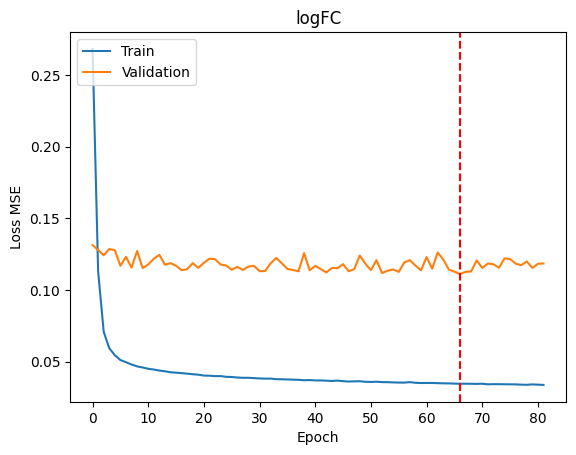

In [ ]:
# Plot training & validation training metrics
# MSE
plt.plot(my_history.history[str('loss')])
plt.plot(my_history.history[str('val_loss')])
plt.title('logFC') # loss is Mean Squared Error (MSE)
plt.ylabel('Loss MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Add vertical line at minimum validation loss of combined dev and hk
min_val_loss = min(my_history.history['val_loss'])
plt.axvline(x=my_history.history['val_loss'].index(min_val_loss), color='red', linestyle='--')

plt.show()

### Performance metrics

In [ ]:
def evaluate_model(X, y, model):
    # Predict the output
    y_pred = model.predict(X)
    # Reshape the arrays to be one-dimensional
    # y = y.values.reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    print
    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    pcc, _ = pearsonr(y, y_pred)
    scc, _ = spearmanr(y, y_pred)

    # Create a DataFrame for the table
    metrics_df = pd.DataFrame({
        'Metric': ['MSE', 'PCC', 'SCC'],
        'Value': [mse, pcc, scc]
    })

    # Print the table
    print(metrics_df)



In [ ]:
evaluate_model(x_val, y_val, main_model)

98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
  Metric     Value
0    MSE  0.111154
1    PCC  0.372640
2    SCC  0.386165


In [ ]:
evaluate_model(x_test, y_test, main_model)

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
  Metric     Value
0    MSE  0.110367
1    PCC  0.367797
2    SCC  0.389188


In [ ]:
model_path = '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_02_spearman_metrics.keras'

main_model_old = tf.keras.models.load_model(model_path)
main_model_old

evaluate_model(x_val, y_val, main_model_old)
evaluate_model(x_test, y_test, main_model_old)

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
  Metric     Value
0    MSE  0.105230
1    PCC  0.424693
2    SCC  0.426482
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
  Metric     Value
0    MSE  0.111295
1    PCC  0.353298
2    SCC  0.357189


### Plotting data - A model perspective

In [ ]:
# main_model.summary()

In [ ]:
# load model
# model_path_first_small_deepSTARR = '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_modified_version_independent.keras'
# model_path_thorben= '/content/drive/MyDrive/PhD/neuro_activity_80K/DeepSTARR_reduced_new_DNA_counts_earlyStop.keras'
# new_model = tf.keras.models.load_model(model_path_thorben)
# Show the model architecture
# new_model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                       │ (None, 198, 128)            │           3,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 198, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool1 (MaxPooling1D)              │ (None, 99, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv1D)                       │ (None, 99, 60)              │          23,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 99, 60)              │             240 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool2 (MaxPooling1D)              │ (None, 49, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 49, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv1D)                       │ (None, 49, 60)              │          18,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 49, 60)              │             240 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool3 (MaxPooling1D)              │ (None, 24, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1440)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          92,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             780 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 416,126 (1.59 MB)

 Trainable params: 138,500 (541.02 KB)

 Non-trainable params: 624 (2.44 KB)

 Optimizer params: 277,002 (1.06 MB)

#### Test predictions on open chromatin regions in wtc11

In [ ]:
# load model:
model_path = '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_02_spearman_metrics.keras'

main_model_old = tf.keras.models.load_model(model_path)
main_model_old

<Functional name=functional_5, built=True>

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense

# # Step 1: Load the existing model
# old_model = tf.keras.models.load_model('path_to_your_model.h5')

# # Step 2: Create a new model with the desired input shape
# new_input = Input(shape=(270, 4))  # New input shape

# # Recreate the model architecture with the new input
# x = new_input
# for layer in old_model.layers[1:-1]:  # Skip the first (input) and last (output) layers
#     if isinstance(layer, tf.keras.layers.Conv1D):
#         # Adjust the Conv1D layers for the new input shape
#         new_layer = tf.keras.layers.Conv1D(
#             filters=layer.filters,
#             kernel_size=layer.kernel_size,
#             activation=layer.activation,
#             padding=layer.padding
#         )
#         x = new_layer(x)
#     else:
#         x = layer(x)

# # Step 3: Add a new output layer
# new_output = Dense(1)(x)  # Single output neuron

# # Create the new model
# new_model = Model(inputs=new_input, outputs=new_output)

# # Step 4: Copy weights from the old model to the new model
# for new_layer, old_layer in zip(new_model.layers[1:-1], old_model.layers[1:-1]):
#     new_layer.set_weights(old_layer.get_weights())

# # Compile the new model
# new_model.compile(optimizer='adam', loss='mse')  # Adjust as needed

# # Print the summary of the new model
# new_model.summary()

Model:  tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05_spearman_metrics.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


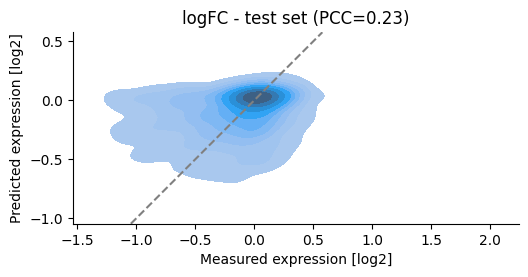

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


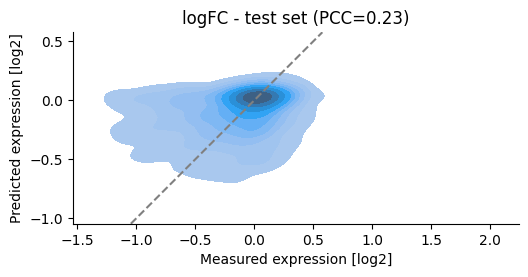

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 458ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


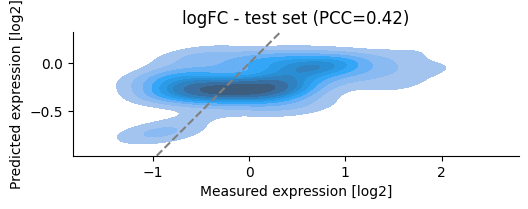

Model:  tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


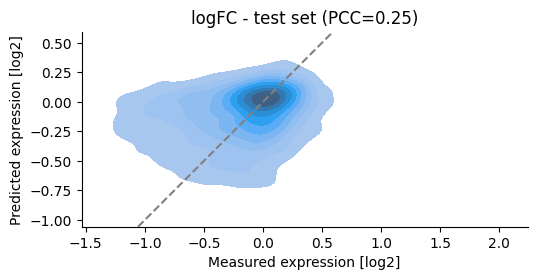

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


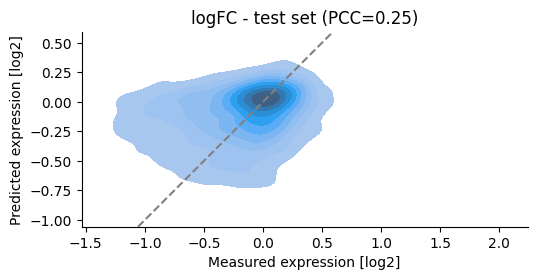

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


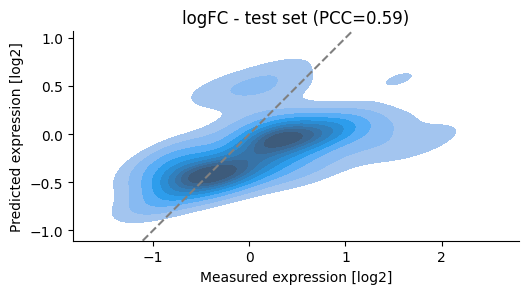

Model:  tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_05_spearman_metrics.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


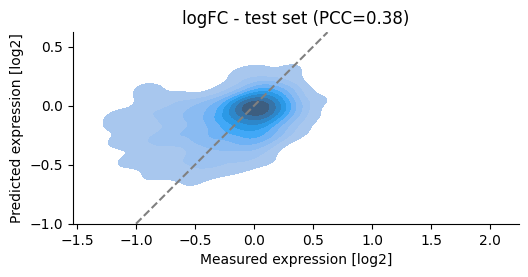

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


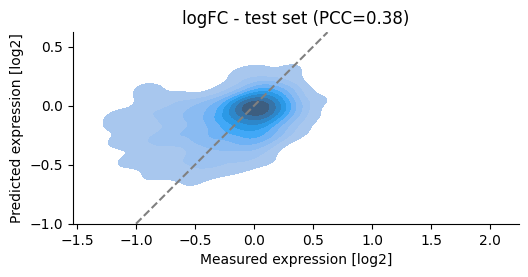

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


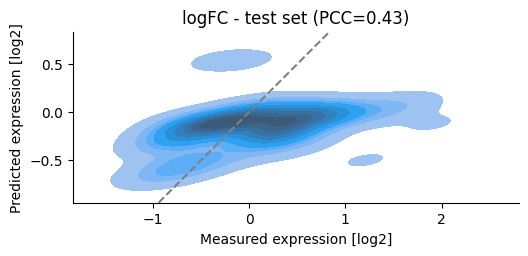

Model:  tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_08_spearman_metrics.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


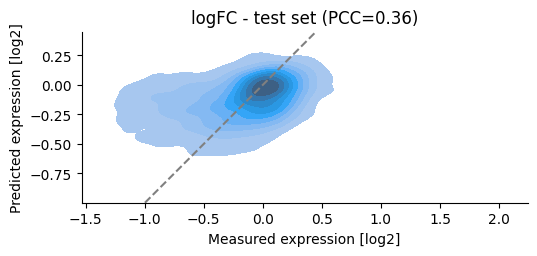

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


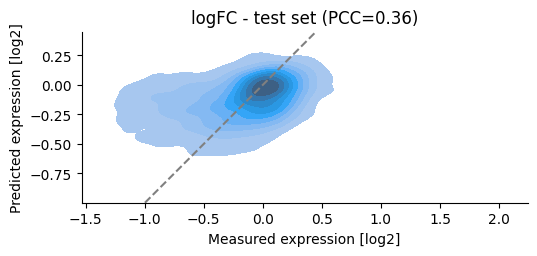

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


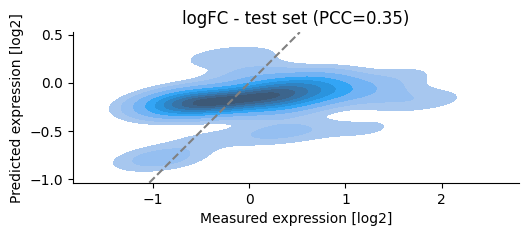

Model:  tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_02_spearman_metrics.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


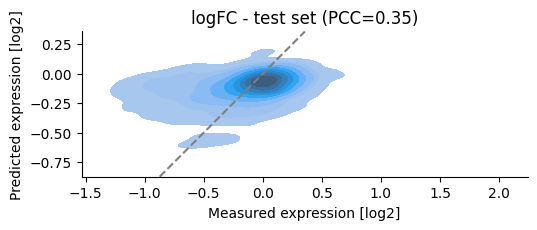

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


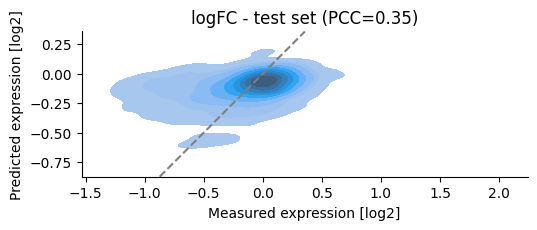

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


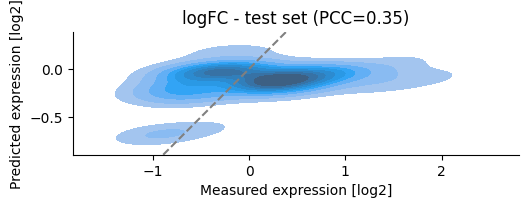

In [ ]:
### smoothscatter plot - useful when there are thousands of points

# takes some time to calculate the kernel density
def my_scatter_density(main_model, X, Y, set, task, params=params):
  pred = main_model.predict(X, batch_size=params['batch_size'])

  # Convert DataFrames to numpy arrays and reshape to be one-dimensional
  # Y = Y.values.reshape(-1)
  pred = pred.reshape(-1)

  g = sns.jointplot(x=Y, y=pred, kind="kde", fill=True)
  g.ax_marg_x.remove() # remove marginal densities
  g.ax_marg_y.remove() # remove marginal densities

  # add expected regression line
  x0, x1 = g.ax_joint.get_xlim()
  y0, y1 = g.ax_joint.get_ylim()
  lims = [max(x0, y0), min(x1, y1)]
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')

  # same axes ranges
  g.ax_joint.set_aspect('equal')

  PCC = str("{0:0.2f}".format(stats.pearsonr(Y, pred)[0]))
  plt.xlabel('Measured expression [log2]')
  plt.ylabel('Predicted expression [log2]')
  plt.title(str(task + ' - ' + set + ' set (PCC=' + PCC + ')'))

  plt.show()

x_open_closed = np.concatenate((x_test, open_x_test), axis=0)
y_open_closed = np.concatenate((y_test, open_y_test), axis=0)
# print plots for test sets
# my_scatter_density(main_model, x_test, y_test, "test", "logFC")
# my_scatter_density(new_model, x_test, y_test, "test", "logFC")


# my_scatter_density(main_model=main_model_old, X=x_test, Y=y_test, set="test", task="logFC", params=params)
# # on open sequences:
# my_scatter_density(main_model=main_model_old, X=open_x_test, Y=open_y_test, set="test", task="logFC", params=params)
model_path_list = ['/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05_spearman_metrics.keras', '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05.keras', '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_05_spearman_metrics.keras', '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_08_spearman_metrics.keras', '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_02_spearman_metrics.keras']
# models = [main_model_old]

for model_path in model_path_list:
  print('Model: ', model_path.split("/")[-1])
  model = tf.keras.models.load_model(model_path)

  print('general prediction: ')
  my_scatter_density(main_model=model, X=x_test, Y=y_test, set="test", task="logFC", params=params)

  print('closed regions: ')
  my_scatter_density(main_model=model, X=x_test, Y=y_test, set="test", task="logFC", params=params)

  print('open regions: ')
  my_scatter_density(main_model=model, X=open_x_test, Y=open_y_test, set="test", task="logFC", params=params)






In [ ]:
models_deepstarr = [file for file in ['/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_modified_version_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_600k_weights_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_second_modified_version_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/DeepSTARR_reduced_new_DNA_counts_earlyStop.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05_spearman_metrics.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_05_spearman_metrics.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_08_spearman_metrics.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_02_spearman_metrics.keras'] if 'open_sequences' not in file]

Model:  tested_elements_DeepSTARR_model.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


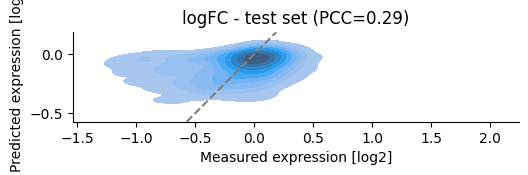

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


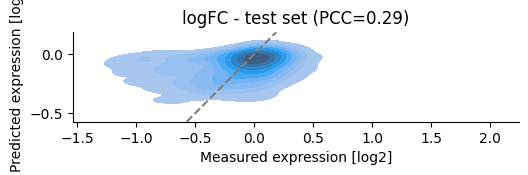

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


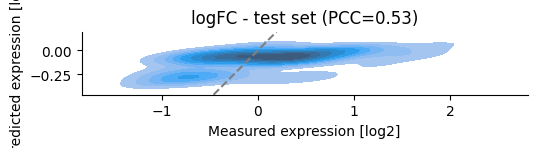

Model:  tested_elements_DeepSTARR_model_modified_version_independent.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


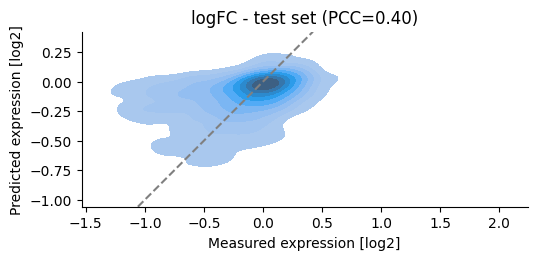

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


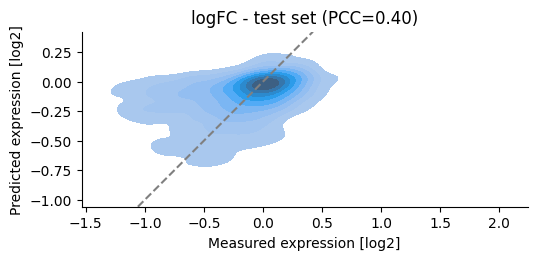

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


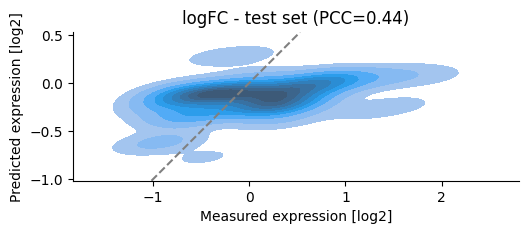

Model:  tested_elements_DeepSTARR_model_600k_weights_independent.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


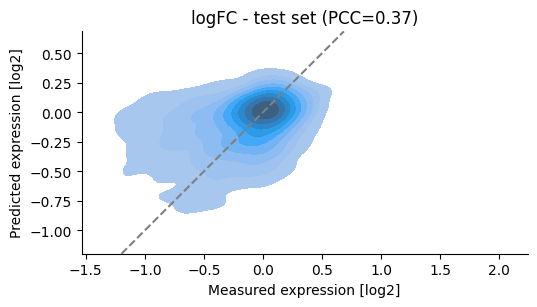

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


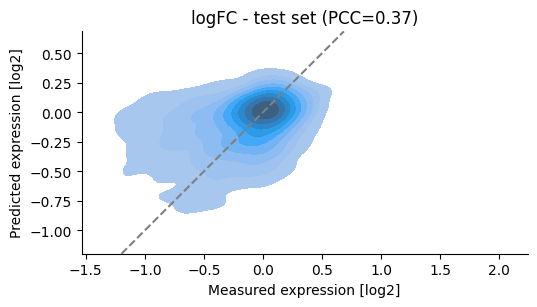

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


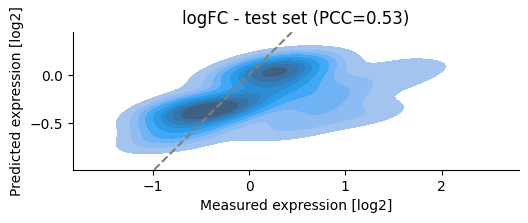

Model:  tested_elements_DeepSTARR_model_second_modified_version_independent.keras
general prediction: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


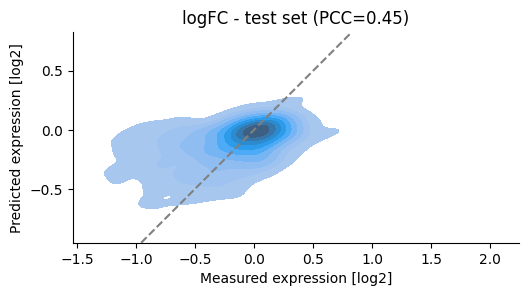

closed regions: 
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


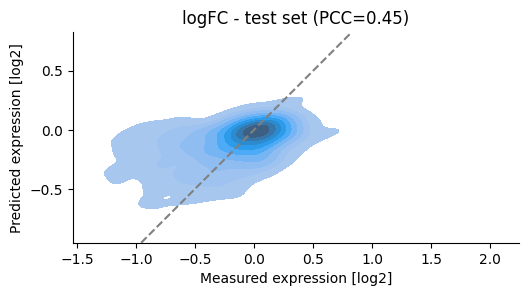

open regions: 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


<ipython-input-49-8feded1a2491>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


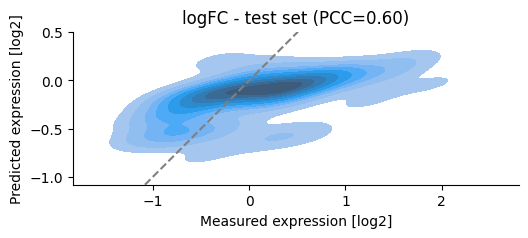

Model:  DeepSTARR_reduced_new_DNA_counts_earlyStop.keras
general prediction: 


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 1440, but received input with shape (64, 1980)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(64, 270, 4), dtype=int64)
  • training=False
  • mask=None

In [ ]:
for model_path in models_deepstarr:
  print('Model: ', model_path.split("/")[-1])
  model = tf.keras.models.load_model(model_path)

  print('general prediction: ')
  my_scatter_density(main_model=model, X=x_test, Y=y_test, set="test", task="logFC", params=params)

  print('closed regions: ')
  my_scatter_density(main_model=model, X=x_test, Y=y_test, set="test", task="logFC", params=params)

  print('open regions: ')
  my_scatter_density(main_model=model, X=open_x_test, Y=open_y_test, set="test", task="logFC", params=params)


In [ ]:
models_deepstarr

['/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_modified_version_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_600k_weights_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_second_modified_version_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/DeepSTARR_reduced_new_DNA_counts_earlyStop.keras']

In [ ]:
import os
import glob

# Define the directory and the pattern
directory = '/content/drive/MyDrive/PhD/neuro_activity_80K'
pattern = '*.keras'  # Example pattern to match all .txt files

# Use glob to find files matching the pattern
matching_files = glob.glob(os.path.join(directory, pattern))

In [ ]:
matching_files

['/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_modified_version_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_600k_weights_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_second_modified_version_independent.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/DeepSTARR_reduced_new_DNA_counts_earlyStop.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_published_model_batch_open_sequences_05_spearman_metrics.keras',
 '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_smaller_model_batch_open_sequences_05_spearman_metrics.keras',
 '/content/drive/MyDrive/PhD/neuro_activity

In [ ]:
type(x_val)
# x_val.shape
print(len(open_x_test))
print(len(x_test))

# Assuming your arrays are named array1 and array2
x_open_closed = np.concatenate((x_test, open_x_test), axis=0)
y_open_closed = np.concatenate((y_test, open_y_test), axis=0)
print(x_open_closed.shape)
print(y_open_closed.shape)

89
3123
(3212, 270, 4)
(3212,)


# Saving your model

---

In [ ]:
# save your model weights and structure as it is
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_modified_version_independent.keras')
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_600k_weights_independent.keras')
# main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model_second_modified_version_independent.keras')